#**스마트폰 센서 데이터 기반 모션 분류**

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.ensemble import RandomForestClassifier

In [ ]:
# 변수의 특성 중요도 계산하기
def plot_feature_importance(importance, names, result_only = False, topn = 'all'):
    feature_importance = np.array(importance)
    feature_name = np.array(names)

    data={'feature_name':feature_name,'feature_importance':feature_importance}
    fi_temp = pd.DataFrame(data)

    #변수의 특성 중요도 순으로 정렬하기
    fi_temp.sort_values(by=['feature_importance'], ascending=False,inplace=True)
    fi_temp.reset_index(drop=True, inplace = True)

    if topn == 'all' :
        fi_df = fi_temp.copy()
    else :
        fi_df = fi_temp.iloc[:topn]

    #변수의 특성 중요도 그래프로 그리기
    if result_only == False :
        plt.figure(figsize=(10,20))
        sns.barplot(x='feature_importance', y='feature_name', data = fi_df)

        plt.xlabel('importance')
        plt.ylabel('feature name')
        plt.grid()

    return fi_df

### 1.데이터 불러오기


* data01_train.csv : 학습 및 검증용
* data01_test.csv : 테스트용
* feature.csv : feature 이름을 계층구조로 정리한 데이터

In [ ]:
# 주어진 데이터 셋을 불러오세요.
data01_train = pd.read_csv('data01_train.csv')
data01_test = pd.read_csv('data01_test.csv')
feature_list = pd.read_csv('features.csv')

In [ ]:
#불필요한 칼럼을 삭제하세요.
data01_train.drop('subject', axis = 1, inplace = True)
data01_test.drop('subject', axis = 1, inplace = True)

## 2.데이터 분석 : 기본정보 살펴보기

### (1) 기본정보 확인하기


In [ ]:
# 전체 데이터의 행, 열 개수를 확인
data01_train.shape

(5881, 562)

In [ ]:
data01_test.shape

(1471, 562)

In [ ]:
# 전체 데이터의 상위 5개 행 확인
data01_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,WALKING_DOWNSTAIRS


In [ ]:
data01_test.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.284379,-0.021981,-0.116683,-0.992490,-0.979640,-0.963321,-0.992563,-0.977304,-0.958142,-0.938850,...,-0.509523,-0.850065,-0.018043,0.092304,0.074220,-0.714534,-0.671943,-0.018351,-0.185733,SITTING
1,0.277440,-0.028086,-0.118412,-0.996620,-0.927676,-0.972294,-0.997346,-0.931405,-0.971788,-0.939837,...,-0.210792,-0.613367,-0.022456,-0.155414,0.247498,-0.112257,-0.826816,0.184489,-0.068699,STANDING
2,0.305833,-0.041023,-0.087303,0.006880,0.182800,-0.237984,0.005642,0.028616,-0.236474,0.016311,...,0.579587,0.394388,-0.362616,0.171069,0.576349,-0.688314,-0.743234,0.272186,0.053101,WALKING
3,0.276053,-0.016487,-0.108381,-0.995379,-0.983978,-0.975854,-0.995877,-0.985280,-0.974907,-0.941425,...,-0.566291,-0.841455,0.289548,0.079801,-0.020033,0.291898,-0.639435,-0.111998,-0.123298,SITTING
4,0.271998,0.016904,-0.078856,-0.973468,-0.702462,-0.869450,-0.979810,-0.711601,-0.856807,-0.920760,...,0.447577,0.214219,0.010111,0.114179,-0.830776,-0.325098,-0.840817,0.116237,-0.096615,STANDING


In [ ]:
# 전체 데이터의 수치형 변수 분포 확인
numeric_cols = data01_train.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-meanFreq()', 'fBodyBodyGyroJerkMag-skewness()',
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)'],
      dtype='object', length=561)


In [ ]:
data01_train[numeric_cols].describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


### (2) 목표 변수 확인하기

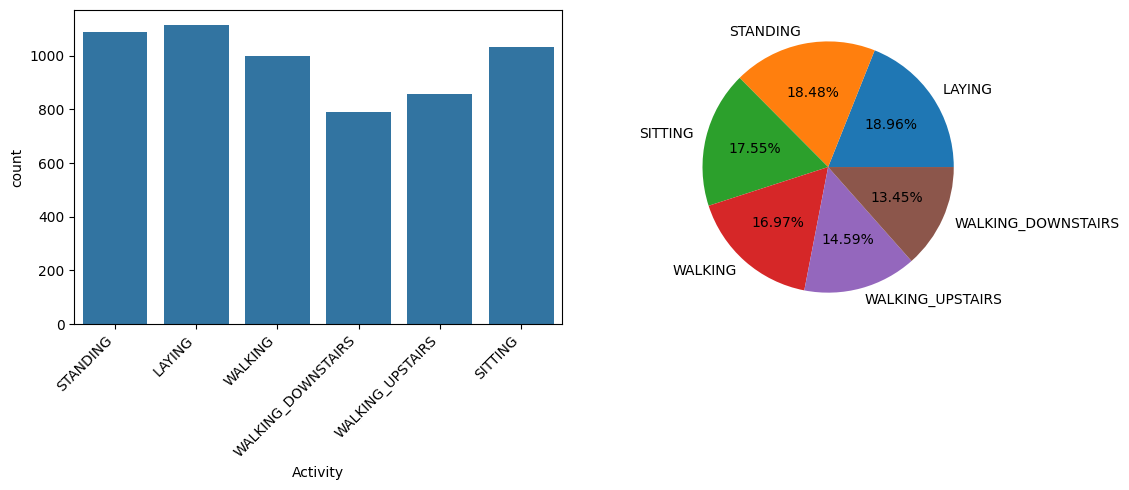

In [ ]:
var = "Activity"
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x = var, data = data01_train)
plt.xticks(rotation=45, ha='right')  # x축 레이블 회전

plt.subplot(1, 2, 2)
temp = data01_train[var].value_counts()
plt.pie(x = temp.values, labels = temp.index, autopct='%.2f%%')

plt.tight_layout()  # 자동으로 레이아웃 조정
plt.show()

### (3) 센서 그룹 데이터: features

In [ ]:
#센서 그룹 데이터의 'sensor'변수의 값 확인
feature_list['sensor'].value_counts()

,count
sensor,
fBodyGyro,79
fBodyAccJerk,79
fBodyAcc,79
tBodyAcc,40
tGravityAcc,40
tBodyAccJerk,40
tBodyGyroJerk,40
tBodyGyro,40
tGravityAccMag,13


In [ ]:
#센서 그룹 데이터의 'agg'변수의 값 확인
feature_list['agg'].value_counts()

,count
agg,
bandsEnergy(),126
arCoeff(),60
std(),33
mad(),33
max(),33
energy(),33
min(),33
entropy(),33
iqr(),33


In [ ]:
#센서 그룹 데이터의 'axis'변수의 값 확인
feature_list['axis'].value_counts()

,count
axis,
X,76
Y,76
Z,76
gravityMean,6
"X,2",5
...,...
"17,32.2",2
"49,64.2",2
"1,24.2",2


## 3.데이터 분석1

#### (1) 데이터 전처리

In [ ]:
data01_train.columns

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-skewness()', 'fBodyBodyGyroJerkMag-kurtosis()',
       'angle(tBodyAccMean,gravity)', 'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'Activity'],
      dtype='object', length=562)

In [ ]:
# 데이터 분할을 위한 전처리
x = data01_train.drop('Activity', axis = 1)
y = data01_train['Activity']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

#### (2) 모델링

In [ ]:
#생성
from sklearn.ensemble import RandomForestClassifier

random_6_model = RandomForestClassifier()

#학습
random_6_model.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
#평가

y_pred = random_6_model.predict(x_test)

print(f'confusion matrix : {confusion_matrix(y_test, y_pred)}')
print(f'classification_report: {classification_report(y_test, y_pred)}')

confusion matrix : [[214   0   0   0   0   0]
 [  0 186  11   0   0   0]
 [  0  11 211   0   0   0]
 [  0   0   0 190   2   1]
 [  0   0   0   0 164   1]
 [  0   0   0   0   0 186]]
classification_report:                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       214
           SITTING       0.94      0.94      0.94       197
          STANDING       0.95      0.95      0.95       222
           WALKING       1.00      0.98      0.99       193
WALKING_DOWNSTAIRS       0.99      0.99      0.99       165
  WALKING_UPSTAIRS       0.99      1.00      0.99       186

          accuracy                           0.98      1177
         macro avg       0.98      0.98      0.98      1177
      weighted avg       0.98      0.98      0.98      1177



#### (3) 변수 중요도 추출

- 변수의 개수가 500개가 넘어가니 모든 변수를 보려고 하면 글자도 겹치고 보기가 매우 어려움
- 가장 높은 중요도를 나타내는 10개를 추출해서 확인해보자(10개는 좀 적은 것 같기도 하고)
- 가장 낮은것도 확인해보면 나중에 빼면 될 것 같기도 하다

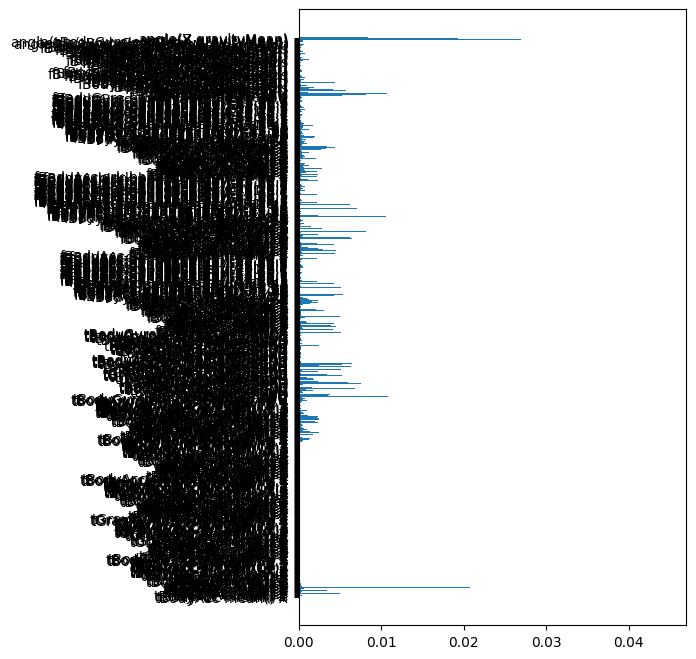

In [ ]:
# 변수 중요도 추출(시각화로 나타내기)
plt.figure(figsize = (5, 8))
plt.barh(list(x), random_6_model.feature_importances_)
plt.show()

,feature_name,feature_importance
0,tGravityAcc-min()-X,0.044743
1,tGravityAcc-min()-Y,0.033160
2,tGravityAcc-energy()-X,0.027506
3,tGravityAcc-mean()-Y,0.027484
4,tGravityAcc-max()-X,0.027108


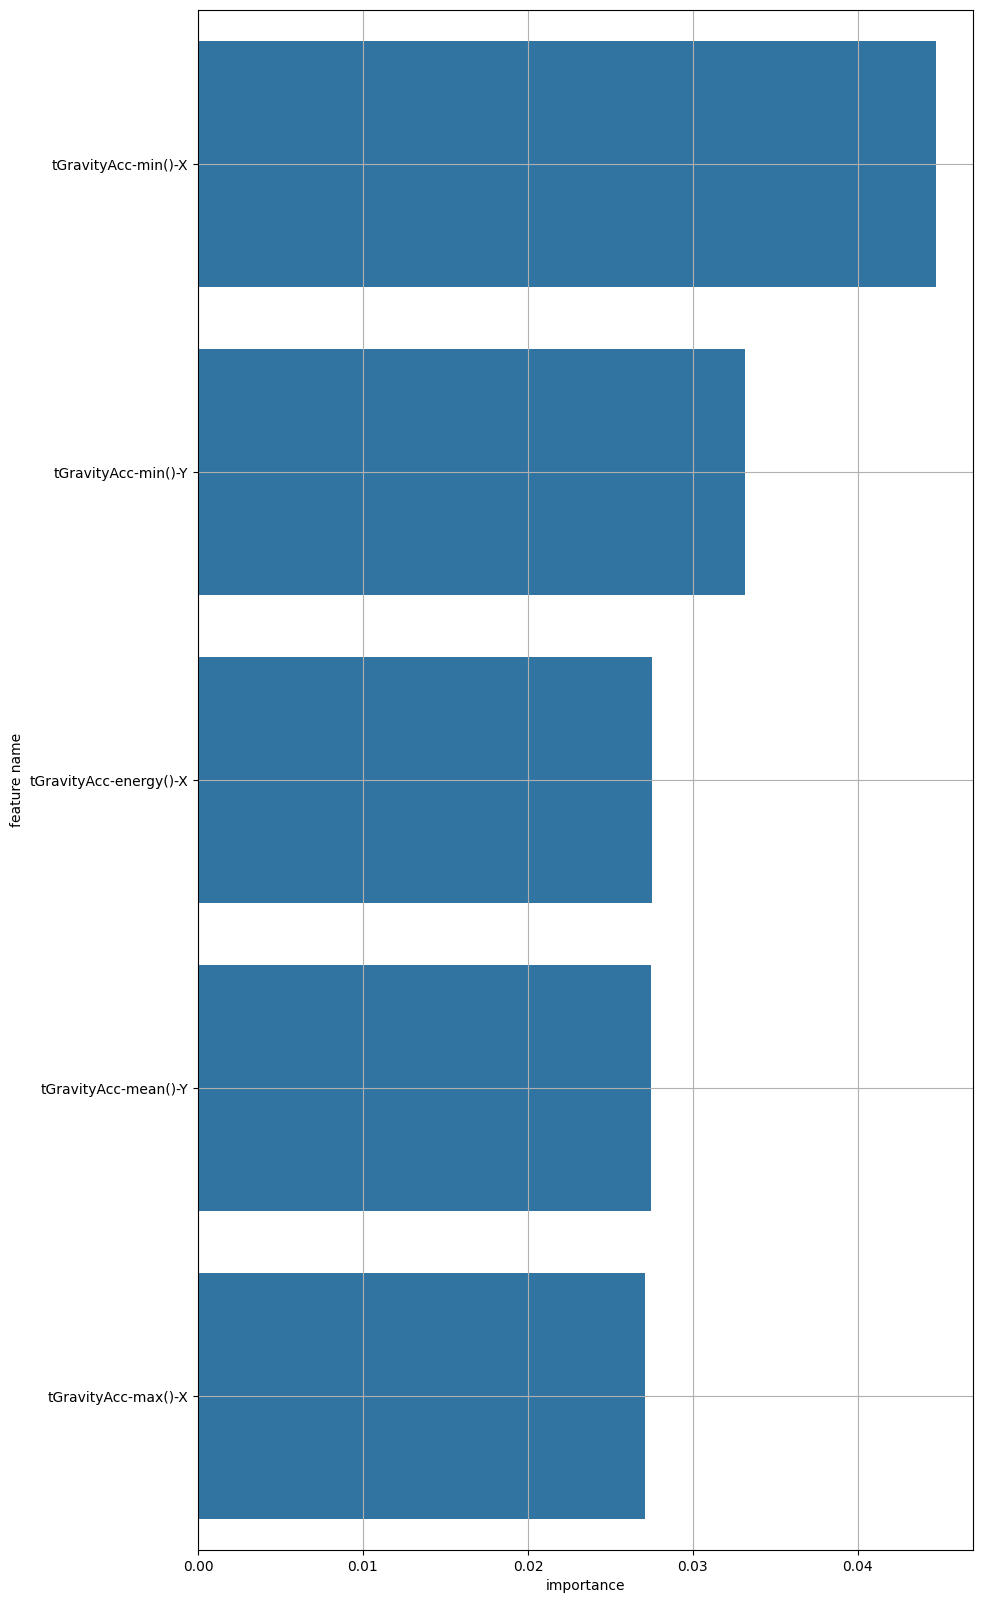

In [ ]:
plot_feature_importance(random_6_model.feature_importances_, feature_names, result_only = False, topn = 5)

In [ ]:
# feature importance 상위 10개만 선택
top_n = 40
feature_importance = random_6_model.feature_importances_
high_indices = np.argsort(feature_importance)[::-1][:top_n]  # 내림차순 정렬 후 상위 10개
low_indices = np.argsort(feature_importance)[:top_n]

# 상위 10개의 feature 이름과 importance
feature_names = np.array(list(x))  # numpy array로 변환
top_features = feature_names[high_indices]
top_importance = feature_importance[high_indices]

# 하위 10개의 feature 이름과 importance
feature_names = np.array(list(x))  # numpy array로 변환
worst_features = feature_names[low_indices]
worst_importance = feature_importance[low_indices]

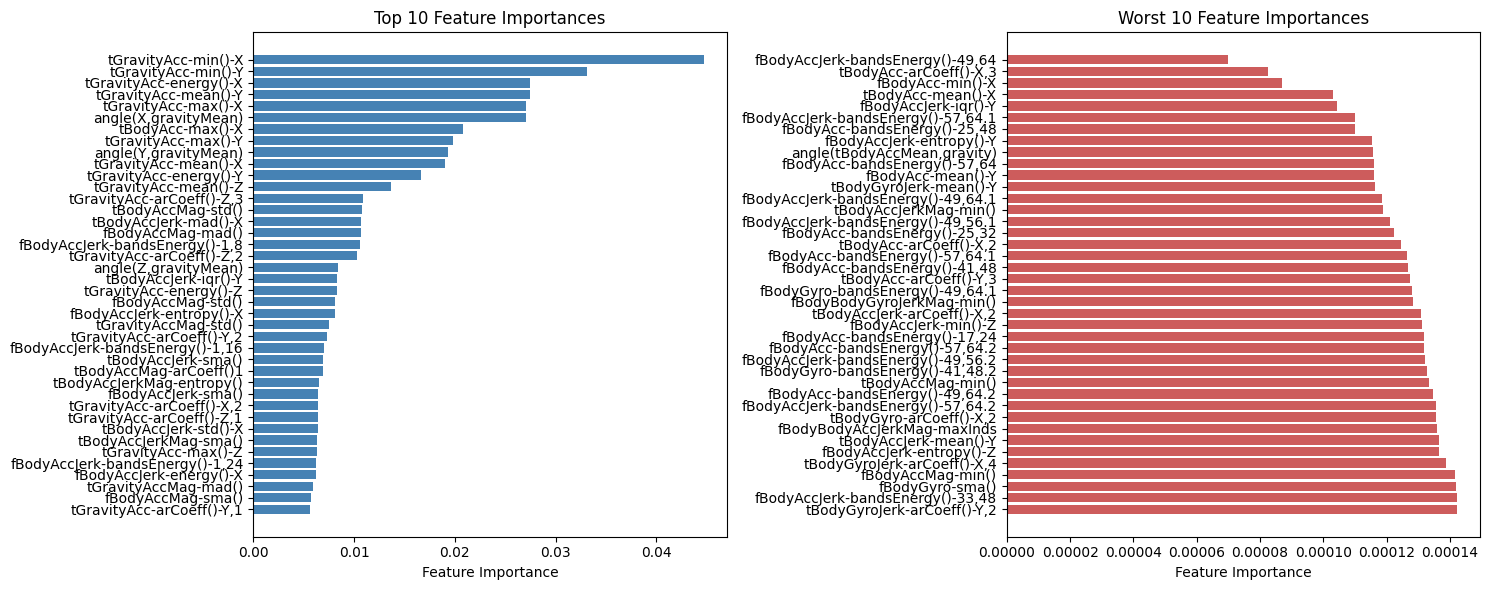

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.barh(top_features, top_importance, color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
plt.barh(worst_features, worst_importance, color='indianred')  # 부드러운 붉은색
plt.xlabel('Feature Importance')
plt.title('Worst 10 Feature Importances')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### (4) 중요도 기반 feature 분석

#### 1) 상위 5, 하위 5개 변수 선정

In [ ]:
# 중요도 상위 top 5
top_features[:10]

array(['tGravityAcc-min()-X', 'tGravityAcc-min()-Y',
       'tGravityAcc-energy()-X', 'tGravityAcc-mean()-Y',
       'tGravityAcc-max()-X', 'angle(X,gravityMean)', 'tBodyAcc-max()-X',
       'tGravityAcc-max()-Y', 'angle(Y,gravityMean)',
       'tGravityAcc-mean()-X'], dtype='<U36')

In [ ]:
# 중요도 하위 top 5
worst_features[:5]

array(['fBodyAccJerk-bandsEnergy()-49,64', 'tBodyAcc-arCoeff()-X,3',
       'fBodyAcc-min()-X', 'tBodyAcc-mean()-X', 'fBodyAccJerk-iqr()-Y'],
      dtype='<U36')

#### 2) 상위 5개 변수에 대한 분석

['STANDING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS' 'WALKING_UPSTAIRS'
 'SITTING']
object


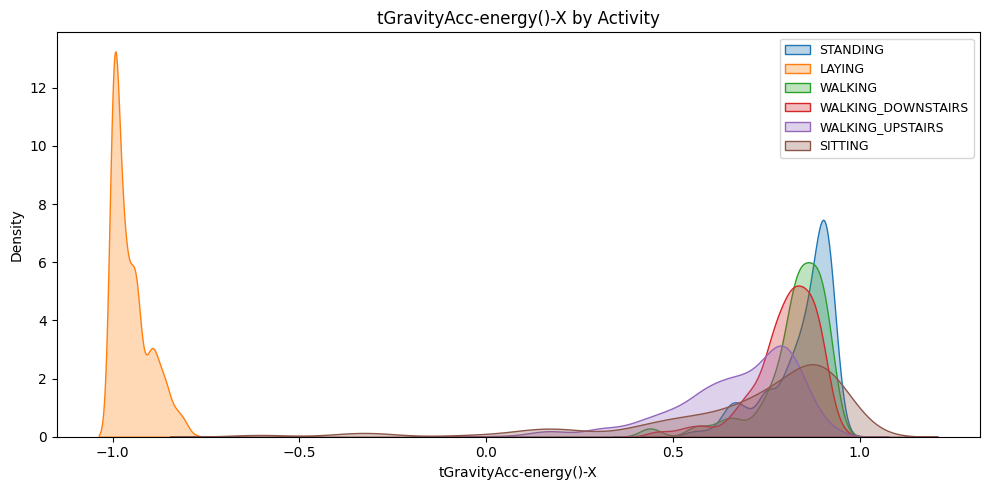

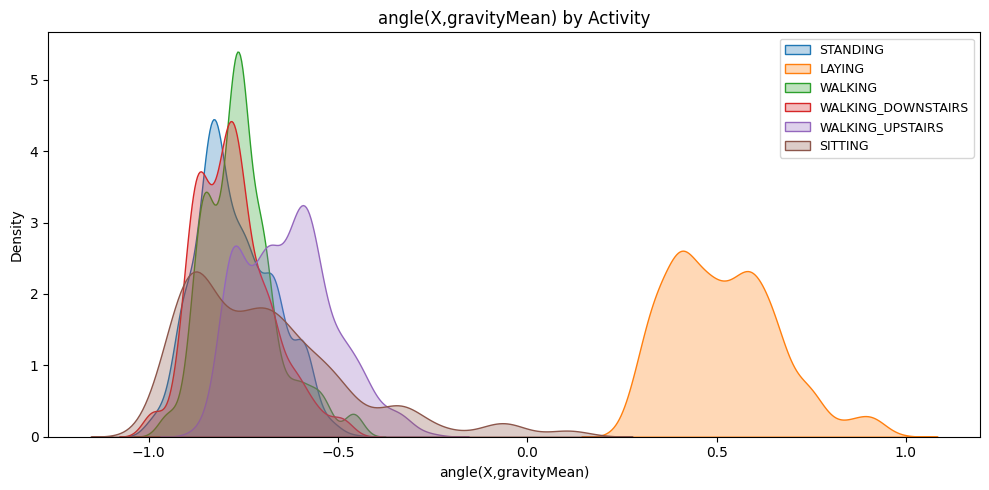

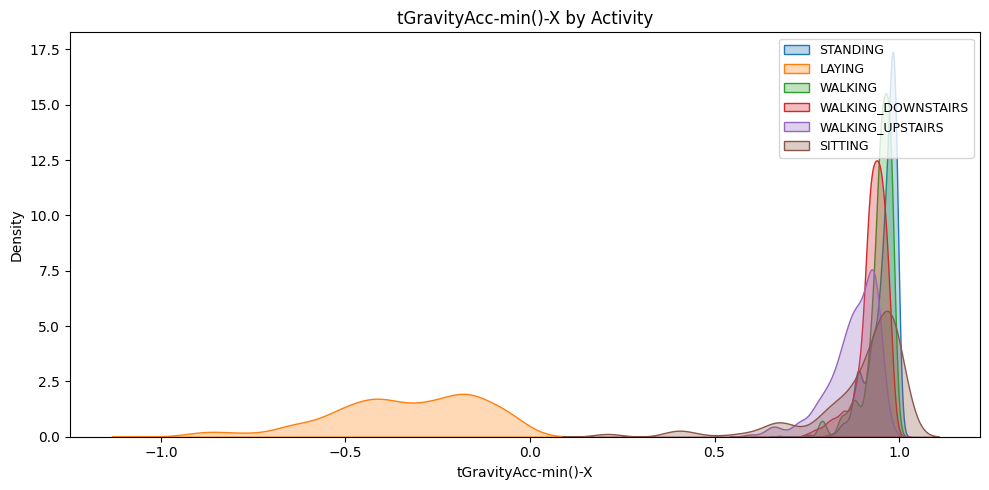

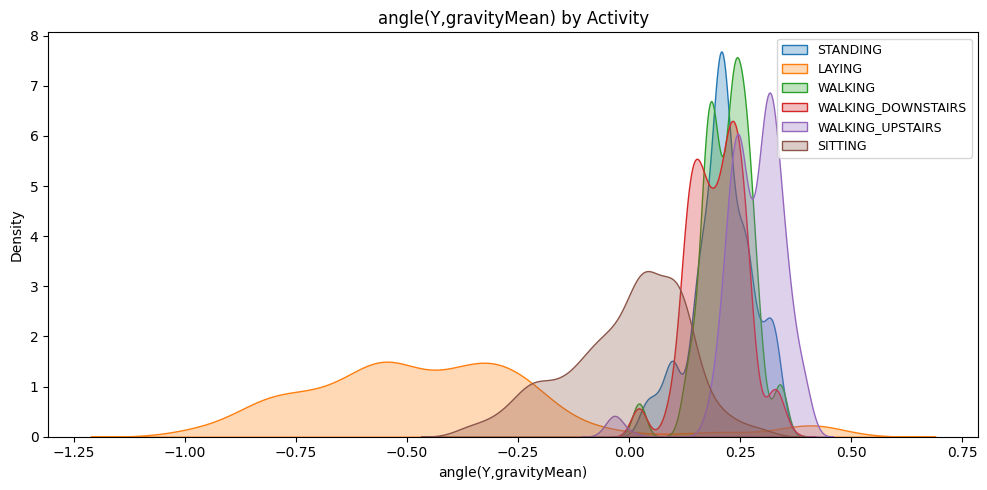

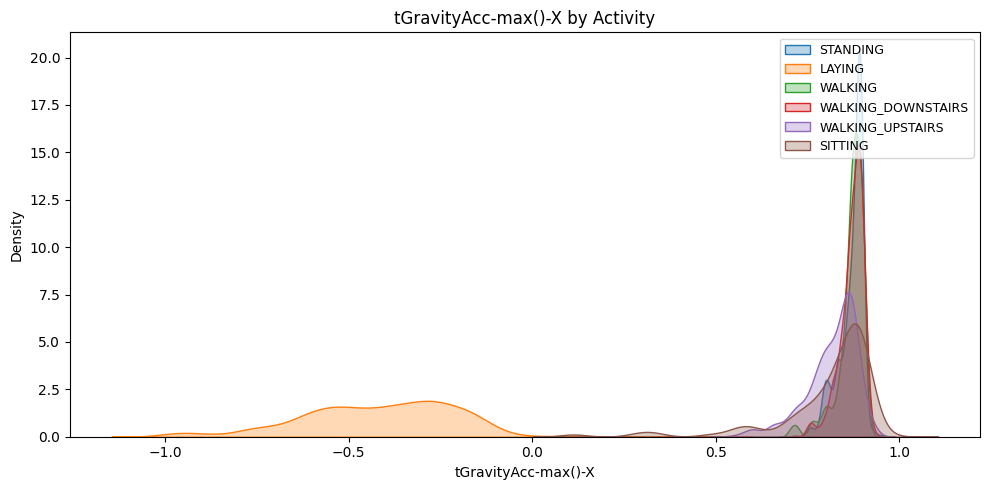

In [ ]:
# Activity 컬럼 확인
print(data01_train['Activity'].unique())
print(data01_train['Activity'].dtype)

# 상위 5개 feature
top_5_features = ['tGravityAcc-energy()-X', 'angle(X,gravityMean)',
                  'tGravityAcc-min()-X', 'angle(Y,gravityMean)',
                  'tGravityAcc-max()-X']

# 각 feature별로 하나씩 그리기
for feature in top_5_features:
    plt.figure(figsize=(10, 5))

    # Activity별로 직접 그리기
    for activity in data01_train['Activity'].unique():
        subset = data01_train[data01_train['Activity'] == activity]
        sns.kdeplot(data=subset[feature], label=activity, fill=True, alpha=0.3)

    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.title(f'{feature} by Activity')
    plt.legend(fontsize=9, loc='upper right')
    plt.tight_layout()
    plt.show()

- 분포끼리 겹치긴 하지만 완전히 겹쳐지지는 않음
- Laying이 특히 잘 구분되고 있음

#### 3) 하위 5개 변수에 대한 분석

['STANDING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS' 'WALKING_UPSTAIRS'
 'SITTING']
object


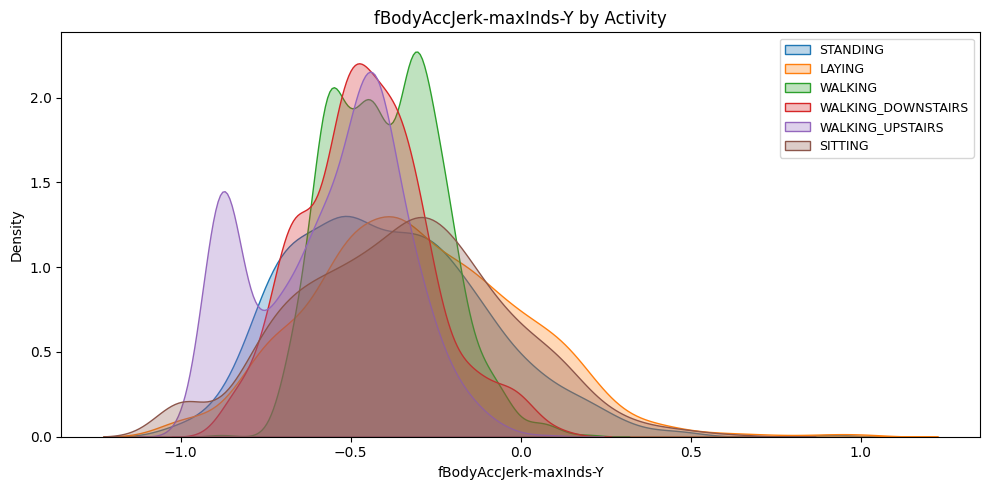

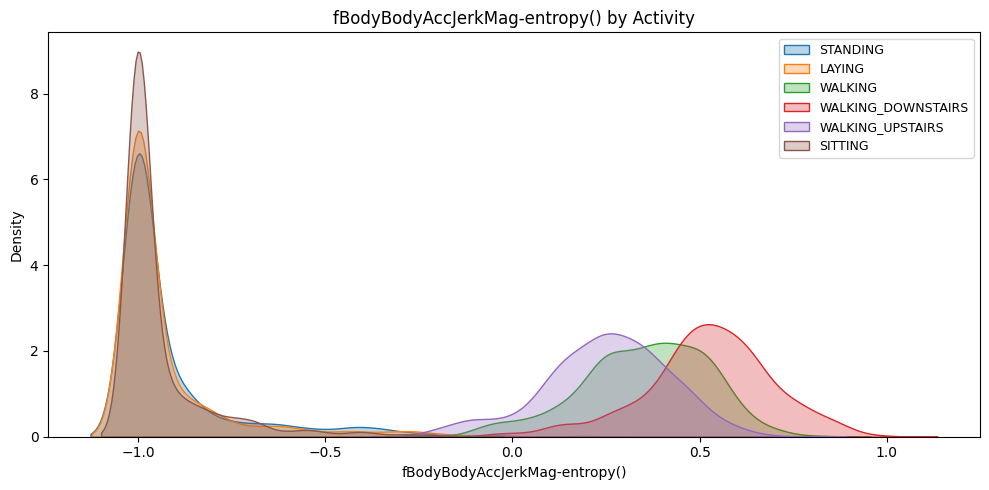

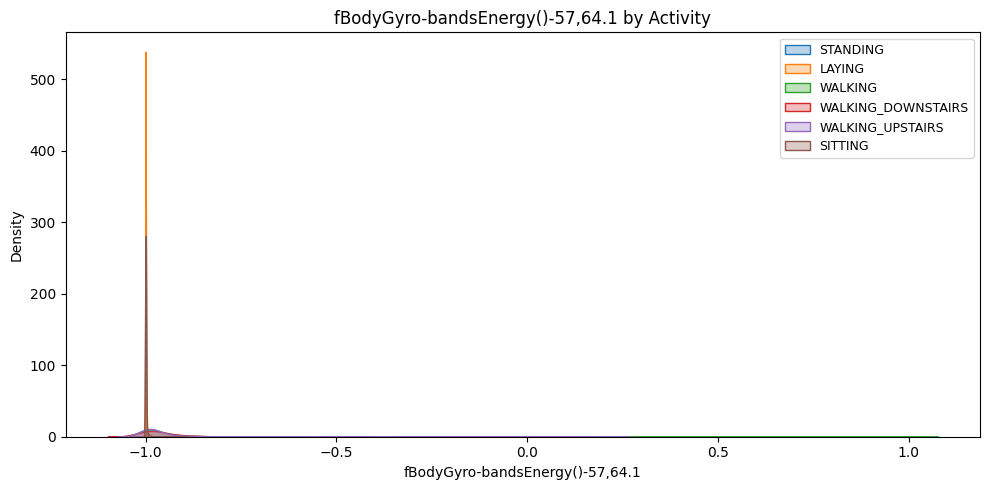

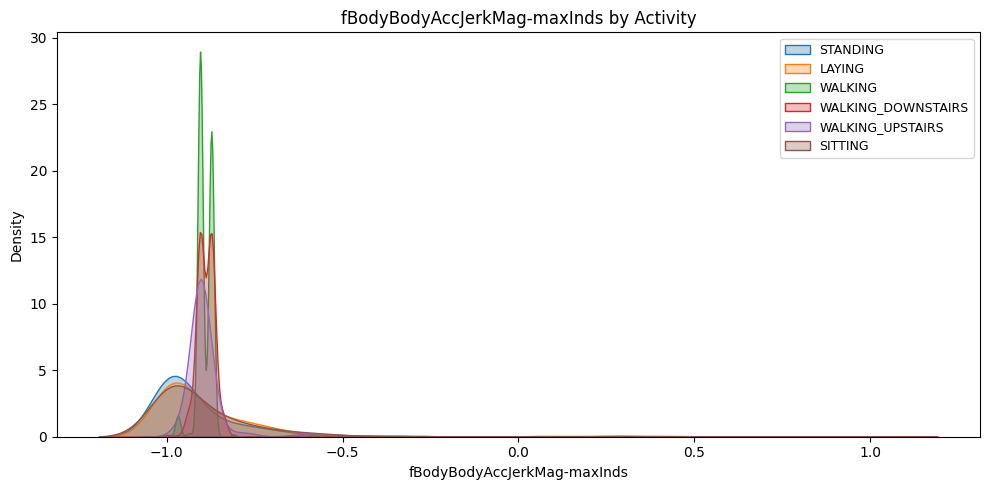

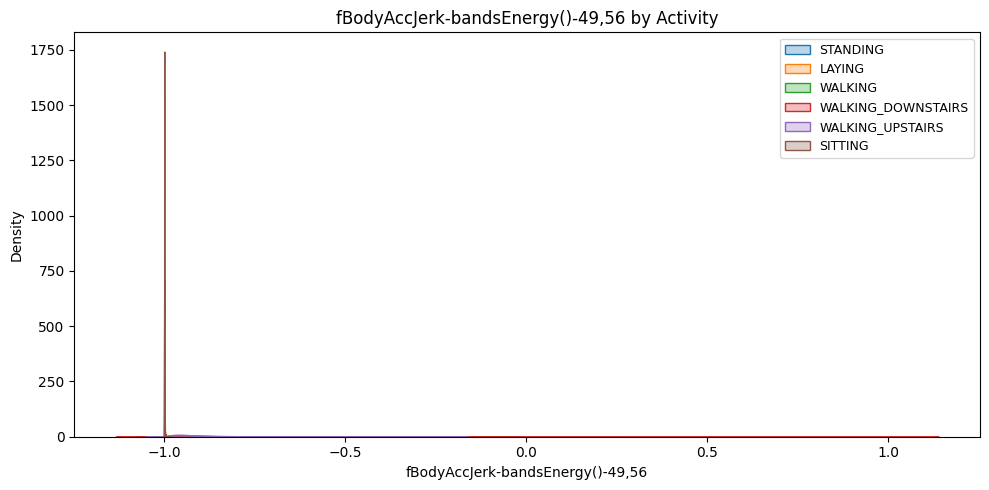

In [ ]:
# Activity 컬럼 확인
print(data01_train['Activity'].unique())
print(data01_train['Activity'].dtype)

# 상위 5개 feature
worst_5_features = ['fBodyAccJerk-maxInds-Y', 'fBodyBodyAccJerkMag-entropy()',
                    'fBodyGyro-bandsEnergy()-57,64.1', 'fBodyBodyAccJerkMag-maxInds',
                    'fBodyAccJerk-bandsEnergy()-49,56']

# 각 feature별로 하나씩 그리기
for feature in worst_5_features:
    plt.figure(figsize=(10, 5))

    # Activity별로 직접 그리기
    for activity in data01_train['Activity'].unique():
        subset = data01_train[data01_train['Activity'] == activity]
        sns.kdeplot(data=subset[feature], label=activity, fill=True, alpha=0.3)

    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.title(f'{feature} by Activity')
    plt.legend(fontsize=9, loc='upper right')
    plt.tight_layout()
    plt.show()

- 분포끼리 겹쳐서 어떤 분포가 어떤 항목을 나타내는지 알아보기 어려움

## 4.데이터 분석2

#### (1) is_dynamic 추가

In [ ]:
#is dynamic 변수를 추가하세요(값 0, 값 1 확인해서!)
# is_dynamic 변수 생성
activity_mapping = {
    'STANDING': 0,
    'SITTING': 0,
    'LAYING': 0,
    'WALKING': 1,
    'WALKING_UPSTAIRS': 1,
    'WALKING_DOWNSTAIRS': 1
}

data01_train['is_dynamic'] = data01_train['Activity'].map(activity_mapping)

# 확인
print(data01_train['is_dynamic'].value_counts())
print(data01_train[['Activity', 'is_dynamic']].head(10))

is_dynamic
0    3234
1    2647
Name: count, dtype: int64
             Activity  is_dynamic
0            STANDING           0
1              LAYING           0
2            STANDING           0
3             WALKING           1
4  WALKING_DOWNSTAIRS           1
5    WALKING_UPSTAIRS           1
6             WALKING           1
7            STANDING           0
8            STANDING           0
9            STANDING           0


In [ ]:
data01_train.drop('Activity', axis = 1, inplace = True)

#### (2) 기본모델 생성

In [ ]:
#데이터 분할 진행(train:val = 8:2 혹은 7:3 권장)
x = data01_train.drop('is_dynamic', axis = 1)
y = data01_train['is_dynamic']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify=y)

In [ ]:
print(f"x_train shape: {x_train.shape}")
print(f"x_val shape: {x_test.shape}")
print(f"y_train 분포:\n{y_train.value_counts()}")
print(f"y_val 분포:\n{y_test.value_counts()}")

x_train shape: (4704, 561)
x_val shape: (1177, 561)
y_train 분포:
is_dynamic
0    2587
1    2117
Name: count, dtype: int64
y_val 분포:
is_dynamic
0    647
1    530
Name: count, dtype: int64


In [ ]:
#RandomForestClassifier로 모델링 진행
random_2_model = RandomForestClassifier()

random_2_model.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = random_2_model.predict(x_test)

In [ ]:
print(f'confusion matrix : {confusion_matrix(y_test, y_pred)}')
print(f'classification_report: {classification_report(y_test, y_pred)}')

confusion matrix : [[647   0]
 [  0 530]]
classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       647
           1       1.00      1.00      1.00       530

    accuracy                           1.00      1177
   macro avg       1.00      1.00      1.00      1177
weighted avg       1.00      1.00      1.00      1177



- 이게 이렇게 나올 수 있나?

#### (3) 변수중요도 상위 5개 분석

In [ ]:
# feature importance 상위 10개만 선택
top_n = 10
feature_importance = random_2_model.feature_importances_
high_indices = np.argsort(feature_importance)[::-1][:top_n]  # 내림차순 정렬 후 상위 10개
low_indices = np.argsort(feature_importance)[:top_n]

# 상위 10개의 feature 이름과 importance
feature_names = np.array(list(x))  # numpy array로 변환
top_features = feature_names[high_indices]
top_importance = feature_importance[high_indices]

# 하위 10개의 feature 이름과 importance
feature_names = np.array(list(x))  # numpy array로 변환
worst_features = feature_names[low_indices]
worst_importance = feature_importance[low_indices]

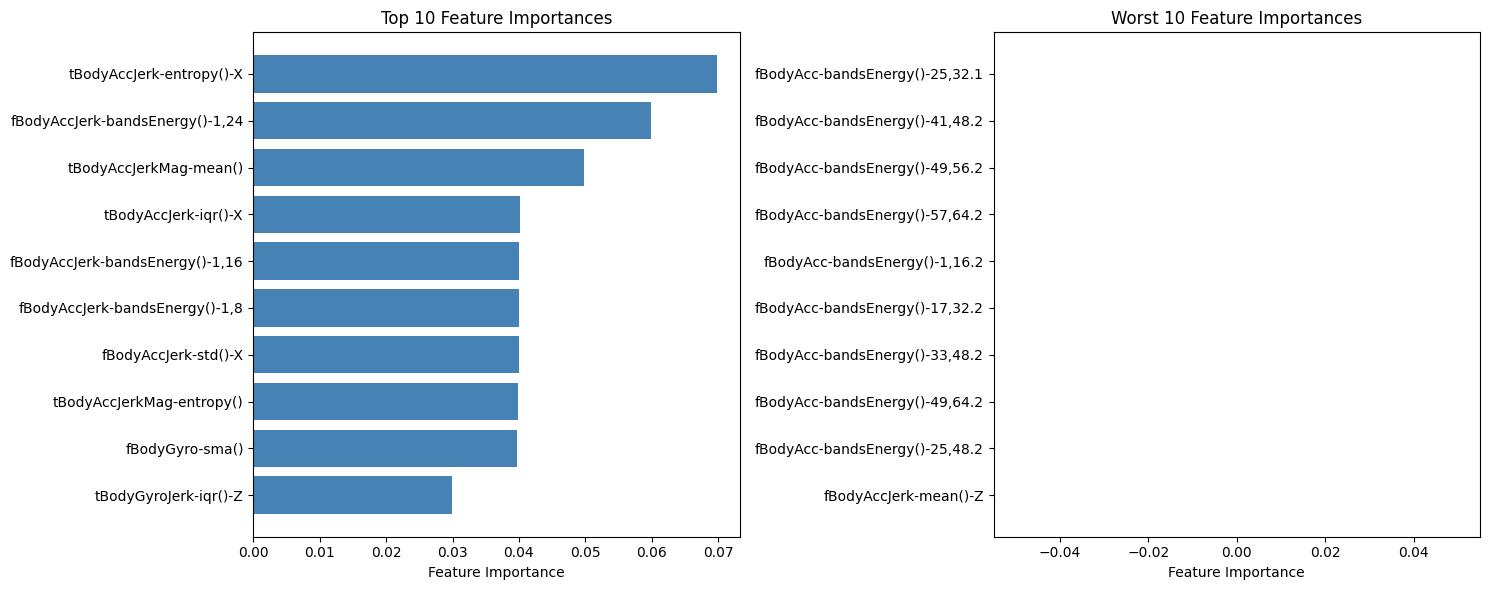

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.barh(top_features, top_importance, color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
plt.barh(worst_features, worst_importance, color='indianred')  # 부드러운 붉은색
plt.xlabel('Feature Importance')
plt.title('Worst 10 Feature Importances')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 5.특성 중요도 저장하기

#### (1) 이름변경 및 저장

In [ ]:
feature_list.columns

Index(['sensor', 'agg', 'axis', 'feature_name'], dtype='object')

In [ ]:
import pandas as pd
import joblib

# 1. 관점1: 6개 행동 구분 모델의 feature importance
importance_6class = pd.DataFrame({
    'feature_name': x.columns,
    'importance_6class': random_6_model.feature_importances_
})

# 2. 관점2: 동적/정적 구분 모델의 feature importance
importance_2class = pd.DataFrame({
    'feature_name': x_train.columns,
    'importance_2class': random_2_model.feature_importances_
})

# 3. feature_list와 하나씩 merge
# 첫 번째 merge: feature_list + importance_6class
result = pd.merge(feature_list, importance_6class, on='feature_name', how='left')

# 두 번째 merge: result + importance_2class
result = pd.merge(result, importance_2class, on='feature_name', how='left')

# 4. 결과 확인
print(result.head(10))
print(f"\n컬럼: {result.columns.tolist()}")
print(f"Shape: {result.shape}")

# 5. joblib로 저장
joblib.dump(result, 'feature_importance_combined.pkl')
print("\n저장 완료: feature_importance_combined.pkl")

     sensor     agg axis       feature_name  importance_6class  \
0  tBodyAcc  mean()    X  tBodyAcc-mean()-X           0.000103   
1  tBodyAcc  mean()    Y  tBodyAcc-mean()-Y           0.000445   
2  tBodyAcc  mean()    Z  tBodyAcc-mean()-Z           0.000187   
3  tBodyAcc   std()    X   tBodyAcc-std()-X           0.005018   
4  tBodyAcc   std()    Y   tBodyAcc-std()-Y           0.000299   
5  tBodyAcc   std()    Z   tBodyAcc-std()-Z           0.000403   
6  tBodyAcc   mad()    X   tBodyAcc-mad()-X           0.003490   
7  tBodyAcc   mad()    Y   tBodyAcc-mad()-Y           0.000242   
8  tBodyAcc   mad()    Z   tBodyAcc-mad()-Z           0.000693   
9  tBodyAcc   max()    X   tBodyAcc-max()-X           0.020835   

   importance_2class  
0           0.000017  
1           0.000042  
2           0.000026  
3           0.000017  
4           0.000006  
5           0.000000  
6           0.000026  
7           0.000000  
8           0.000000  
9           0.020171  

컬럼: ['sensor', 'agg